<a href="https://colab.research.google.com/github/lkostenko/ds_homeworks/blob/main/Kostenko_HW_2_1_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B2%D1%96%D0%B4_%D0%B1%D0%B0%D0%B3%D0%B0%D1%82%D1%8C%D0%BE%D1%85_%D0%B7%D0%BC%D1%96%D0%BD%D0%BD%D0%B8%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [2]:
df = pd.read_csv('cars.csv')

In [3]:
df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [4]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [6]:
df.dtypes

,0
Car_ID,int64
Brand,object
Model,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,int64
Engine,int64


In [7]:
object_cols = df.select_dtypes(include='object')

In [8]:
for col in object_cols:
    print(f'{col}: {df[col].nunique()}, {df[col].unique()}')

Brand: 11, ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']
Model: 58, ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']
Fuel_Type: 2, ['Petrol' 'Diesel']
Transmission: 2, ['Manual' 'Automatic']
Owner_Type: 3, ['First' 'Second' 'Third']


В наборі даних 13 колонок, з них 8 числових та 5 категоріальних.

Серед категоріальних колонок:

- 2 бінарні (мають лише 2 значення): Fuel_Type, Transmission

- 2 мультикатегоріальні без порядку (більше 2 значень, відсутнє відношення порядку): Brand, Model

- 1 мультикатегоріальна з порядком (можна встановити відношення порядку): Owner_Type (First < Second < Third)

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [9]:
X = df.drop(columns=['Price'])
y = df['Price']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=12)

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 12), (20, 12), (80,), (20,))

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

### 4.1 Кодування колонок з бінарними значеннями

In [12]:
binar_cols = ['Fuel_Type', 'Transmission']

for col in binar_cols:
    print(f'{col}:\n{X_train[col].value_counts()}\n')

Fuel_Type:
Fuel_Type
Petrol    41
Diesel    39
Name: count, dtype: int64

Transmission:
Transmission
Automatic    49
Manual       31
Name: count, dtype: int64



In [13]:
Fuel_Type_Code = {'Diesel': 0, 'Petrol': 1}

In [14]:
X_train['Fuel_Type_Code'] = X_train.Fuel_Type.map(Fuel_Type_Code)
X_test['Fuel_Type_Code'] = X_test.Fuel_Type.map(Fuel_Type_Code)

In [15]:
Transmission_Code = {'Manual': 0, 'Automatic': 1}

In [16]:
X_train['Transmission_Code'] = X_train['Transmission'].map(Transmission_Code)
X_test['Transmission_Code']  = X_test['Transmission'].map(Transmission_Code)

### 4.2 Кодування колонки Brand

In [17]:
enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])
enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [18]:
one_hot = enc.transform(X_train[['Brand']]).toarray()
one_hot

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.

In [19]:
enc.categories_[0]

array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
       'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)

In [20]:
X_train[enc.categories_[0]] = one_hot

In [21]:
one_hot_test = enc.transform(X_test[['Brand']]).toarray()
X_test[enc.categories_[0]] = one_hot_test

### 4.3 Owner_Type

In [22]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

### 4.4 Model

In [23]:
def model_type(model):
    sedans = ['Corolla', 'Civic', 'City', 'Verna', 'A4', '3 Series', 'C-Class', 'E-Class', '5 Series', 'A6', 'Camry']
    hatchbacks = ['Swift', 'Polo', 'Altroz', 'Figo', 'Ameo', 'Tiago', 'Santro', 'S-Cross']
    suvs = ['Creta', 'Nexon', 'Harrier', 'Scorpio', 'Fortuner', 'Tiguan', 'X1', 'X3', 'X5', 'GLC', 'GLE', 'GLA', 'Ranger', 'EcoSport', 'Thar', 'Vitara', 'WR-V', 'T-Roc', 'XUV300']

    if model in sedans:
        return 'Sedan'
    elif model in hatchbacks:
        return 'Hatchback'
    elif model in suvs:
        return 'SUV'
    else:
        return 'Other'



In [24]:
X_train['Model_type'] = X_train['Model'].apply(model_type)
X_test['Model_type']  = X_test['Model'].apply(model_type)

In [25]:
enc_model = preprocessing.OneHotEncoder()

In [26]:
enc_model.fit(X_train[['Model_type']])

OneHotEncoder()

In [27]:
one_hot_train = enc_model.transform(X_train[['Model_type']]).toarray()

In [28]:
X_train[enc_model.categories_[0]] = one_hot_train

In [29]:
one_hot_test = enc_model.transform(X_test[['Model_type']]).toarray()

In [30]:
X_test[enc_model.categories_[0]] = one_hot_test

Очікуваний результат після трансформацій:

In [31]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_type,Hatchback,Other,SUV,Sedan
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,SUV,0.0,0.0,1.0,0.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other,0.0,1.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan,0.0,0.0,0.0,1.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,0.0,1.0,0.0,0.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,SUV,0.0,0.0,1.0,0.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_type,Hatchback,Other,SUV,Sedan
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other,0.0,1.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Hatchback,1.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,0.0,1.0,0.0,0.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Other,0.0,1.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other,0.0,1.0,0.0,0.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [32]:
X_train_num = X_train.select_dtypes(include='number')
X_test_num  = X_test.select_dtypes(include='number')

In [33]:
X_train_num.drop(columns=['Car_ID'], inplace=True)
X_test_num.drop(columns=['Car_ID'], inplace=True)

In [34]:
train_final = pd.concat([X_train_num, y_train], axis=1)

In [35]:
train_final.corr()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Hatchback,Other,SUV,Sedan,Price
Year,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,0.248515,-0.200603,-0.256523,0.202517,-0.150454,-3.743663e-02,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,-0.014499,0.550980,-0.372377,0.013692,-5.018934e-02,-0.233769
Kilometers_Driven,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,-0.332351,-0.066491,0.095879,-0.247042,-0.009761,5.737237e-02,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.001772,-0.419551,0.297552,-0.004147,1.431364e-02,-0.083951
Mileage,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.070112,-0.399164,-0.152701,-0.134105,-0.296480,3.586300e-01,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.026624,0.375795,-0.098333,-0.145732,-3.664824e-02,-0.638404
Engine,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,-0.174455,0.456296,0.085153,0.287119,0.184231,-1.544910e-01,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.196106,-0.407415,0.172490,0.112156,1.552241e-02,0.710561
Power,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.076357,0.586910,0.157050,0.372652,0.240501,-1.918101e-01,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.204309,-0.408684,0.129552,0.071757,1.146785e-01,0.849137
Seats,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,-0.412468,-0.070099,0.123674,-0.108079,-0.161451,2.003031e-01,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.043849,-0.121205,0.246982,-0.030606,-1.517812e-01,0.000979
Fuel_Type_Code,0.248515,-0.332351,-0.070112,-0.174455,0.076357,-0.412468,1.000000,-0.005775,-0.008336,-0.048475,0.109812,-1.614248e-01,-0.007121,-0.235225,0.148511,-0.048475,0.066164,-0.008336,0.125010,0.281122,0.316796,-0.255839,-0.070745,1.125352e-01,-0.110782
Transmission_Code,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,-0.005775,1.000000,0.265132,0.283188,-0.122816,-2.186198e-01,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,0.005886,-0.203960,-0.029166,-0.105453,3.335527e-01,0.680731
Audi,-0.256523,0.095879,-0.152701,0.085153,0.157050,0.123674,-0.008336,0.265132,1.000000,-0.118678,-0.118678,-8.606630e-02,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.203925,-0.133092,0.290786,-0.231296,4.166667e-02,0.328858
BMW,0.202517,-0.247042,-0.134105,0.287119,0.372652,-0.108079,-0.048475,0.283188,-0.118678,1.000000,-0.126761,-9.192771e-02,-0.101380,-0.081680,-0.091928,-0.126761,-0.134568,-0.118678,-0.110250,0.009076,-0.142156,-0.086798,0.090796,1.186782e-01,0.477522


In [36]:
corr_matrix = train_final.corr()

In [37]:
def highlight_strong(val):
    color = 'yellow' if abs(val) > 0.5 else ''
    return f'background-color: {color}'

corr_matrix.style.map(highlight_strong, subset=['Price'])

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Hatchback,Other,SUV,Sedan,Price
Year,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,0.248515,-0.200603,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,-0.014499,0.550980,-0.372377,0.013692,-0.050189,-0.233769
Kilometers_Driven,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,-0.332351,-0.066491,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.001772,-0.419551,0.297552,-0.004147,0.014314,-0.083951
Mileage,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.070112,-0.399164,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.026624,0.375795,-0.098333,-0.145732,-0.036648,-0.638404
Engine,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,-0.174455,0.456296,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.196106,-0.407415,0.172490,0.112156,0.015522,0.710561
Power,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.076357,0.586910,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.204309,-0.408684,0.129552,0.071757,0.114679,0.849137
Seats,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,-0.412468,-0.070099,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.043849,-0.121205,0.246982,-0.030606,-0.151781,0.000979
Fuel_Type_Code,0.248515,-0.332351,-0.070112,-0.174455,0.076357,-0.412468,1.000000,-0.005775,-0.008336,-0.048475,0.109812,-0.161425,-0.007121,-0.235225,0.148511,-0.048475,0.066164,-0.008336,0.125010,0.281122,0.316796,-0.255839,-0.070745,0.112535,-0.110782
Transmission_Code,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,-0.005775,1.000000,0.265132,0.283188,-0.122816,-0.218620,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,0.005886,-0.203960,-0.029166,-0.105453,0.333553,0.680731
Audi,-0.256523,0.095879,-0.152701,0.085153,0.157050,0.123674,-0.008336,0.265132,1.000000,-0.118678,-0.118678,-0.086066,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.203925,-0.133092,0.290786,-0.231296,0.041667,0.328858
BMW,0.202517,-0.247042,-0.134105,0.287119,0.372652,-0.108079,-0.048475,0.283188,-0.118678,1.000000,-0.126761,-0.091928,-0.101380,-0.081680,-0.091928,-0.126761,-0.134568,-0.118678,-0.110250,0.009076,-0.142156,-0.086798,0.090796,0.118678,0.477522


Mileage має негативну кореляцію - чим більше пробіг, тим нижча ціна

Engine і Power мають позитивну кореляцію - більший двигун / потужність - дорожчі автомобілі

Transmission_Code ( 1 = автомат, 0 = механіка) - машини на автоматі дорожчі

Інші колонки не мають настільки сильної лінійної кореляції з ціною

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [38]:
lr = LinearRegression()

In [39]:
lr.fit(X_train_num, y_train)

LinearRegression()

In [40]:
y_train_pred = lr.predict(X_train_num)
y_test_pred  = lr.predict(X_test_num)

In [41]:
# RMSE для тренувального набору
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"RMSE на тренувальному наборі: {rmse_train:.2f}")

# RMSE для тестового набору
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"RMSE на тестовому наборі: {rmse_test:.2f}")


RMSE на тренувальному наборі: 189573.10
RMSE на тестовому наборі: 250084.04


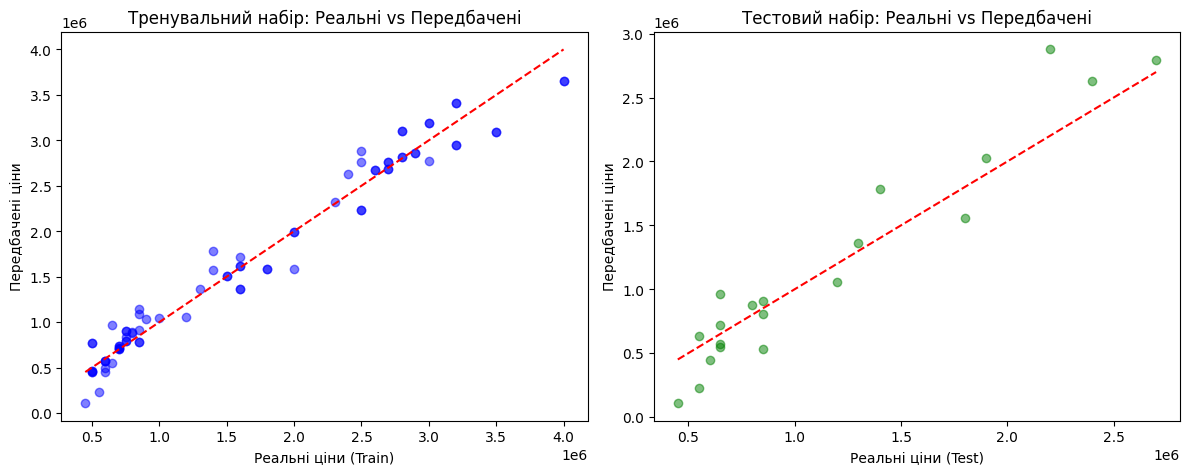

In [42]:

# Графік для тренувального набору
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel("Реальні ціни (Train)")
plt.ylabel("Передбачені ціни")
plt.title("Тренувальний набір: Реальні vs Передбачені")

# Графік для тестового набору
plt.subplot(1,2,2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Реальні ціни (Test)")
plt.ylabel("Передбачені ціни")
plt.title("Тестовий набір: Реальні vs Передбачені")

plt.tight_layout()
plt.show()


Результати: RMSE на тренуванні ~189,525, на тесті ~248,435.


Різниця між помилками на тренувальному та тестовому наборах є, але вона не критична (тестова помилка більша приблизно на 30%)

На обох графіках (Train та Test) точки вишикувані вздовж червоної діагональної лінії. Це підтверджує, що лінійна регресія підходить для опису залежності в цих даних.



На тренувальному наборі точки лежать дуже щільно до лінії, що вказує на високу якість підгонки.

На тестовому наборі точки також слідують за лінією, хоча розкид трохи більший, ніж на тренувальному (що підтверджує різницю в RMSE). Проте немає хаотично розкиданих точок, модель чітко "розуміє", які машини дешевші, а які дорожчі.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [43]:
scaler = StandardScaler()

In [44]:
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

In [45]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_num.columns, index=X_train_num.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test_num.columns,  index=X_test_num.index)

In [46]:
lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

LinearRegression()

In [47]:
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_scaled.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

coef_df


,Feature,Coefficient
4,Power,530598.646111
8,Audi,227381.114667
6,Fuel_Type_Code,-201397.042929
9,BMW,181126.568397
15,Mercedes,175230.095056
13,Mahindra,-170083.077545
12,Hyundai,-131906.545688
1,Kilometers_Driven,-116402.548975
10,Ford,-109465.944700
2,Mileage,-108552.821637


Найбільші коефіціенти: Потужність двигуна і престиж бренду (Audi, BMW, Mercedes).

Все відповідає очікуванням ринку авто - преміум бренди та високий Power підвищують ціну, а велика витрата палива, пробіг і масові бренди знижують ціну.

є два результати, які виглядають дивно:
- Engine (-9 811): Вплив дуже малий і навіть від'ємний.
Я вважаю, так відбувається через мультиколінеарність. Є змінні Power і Engine. Вони дуже сильно корелюють між собою (потужність залежить від об'єму). Модель вибрала Power як головного предиктора, а Engine став зайвим, тому його вага впала майже до нуля або навіть пішла в мінус, компенсуючи похибки Power.

- Year (-136): Вплив практично нульовий. Рік - начебто мав бути важливим фактором. Але тут його вплив, ймовірно, перебив Kilometers_Driven (нові машини мають малий пробіг). Для лінійної регресії пробіг виявився кращим індикатором зносу, ніж календарний рік.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [48]:
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)


In [49]:
model_sm = sm.OLS(y_train, X_train_sm).fit()

In [50]:
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     74.47
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           4.02e-34
Time:                        17:57:34   Log-Likelihood:                -1085.7
No. Observations:                  80   AIC:                             2217.
Df Residuals:                      57   BIC:                             2272.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.51e+0

In [51]:
significant_features = ['Kilometers_Driven', 'Power', 'Fuel_Type_Code', 'Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Volkswagen', 'Other', 'SUV', 'Sedan']

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [52]:
X_train_sig = X_train_scaled[significant_features]
X_test_sig  = X_test_scaled[significant_features]

In [53]:
X_train_sig_sm = sm.add_constant(X_train_sig)
lr_sig = sm.OLS(y_train, X_train_sig_sm).fit()

In [54]:
print(lr_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     84.58
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           3.10e-36
Time:                        17:57:34   Log-Likelihood:                -1100.0
No. Observations:                  80   AIC:                             2232.
Df Residuals:                      64   BIC:                             2270.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.83e+0

R-squared та Adjusted R-squared

R²: 0.952

Adj. R²: 0.941

Порівняно з повною моделлю (R² ≈ 0.966, Adj. R² ≈ 0.953):

R² трохи знизилось (~1.4%), що логічно, бо ми прибрали незначущі ознаки.

Падіння невелике - більшість пояснювальної сили збереглась, модель стала простішою та більш інтерпретованою.

ознаки (Kilometers_Driven, Ford, Maruti, Volkswagen, Other) стали незначущими (p > 0.05) у цій  моделі, можливо через мультиколінеарність з іншими змінними.


 параметр Cond. No. в самому низу таблиці:
 Було: 1.03e+16 (Величезне число - Критична мультиколінеарність).Стало: 5.21

 Тепер коефіцієнти моделі є стабільними та надійними. Математично ця модель набагато здоровіша.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [55]:
coef_df = pd.DataFrame({'Feature': model_sm.params.index,'p_value': model_sm.pvalues})
coef_df


,Feature,p_value
const,const,7.224154e-56
Year,Year,9.980698e-01
Kilometers_Driven,Kilometers_Driven,3.252661e-02
Mileage,Mileage,5.199649e-02
Engine,Engine,8.826495e-01
Power,Power,3.462965e-10
Seats,Seats,4.602737e-01
Fuel_Type_Code,Fuel_Type_Code,2.134923e-05
Transmission_Code,Transmission_Code,5.068165e-02
Audi,Audi,7.396405e-11


In [56]:
selected_features = coef_df[coef_df['p_value'] < 0.25]['Feature'].tolist()

In [57]:
features_p25 = [feat for feat in selected_features if feat != 'const']

In [58]:
features_p25

['Kilometers_Driven',
 'Mileage',
 'Power',
 'Fuel_Type_Code',
 'Transmission_Code',
 'Audi',
 'BMW',
 'Ford',
 'Honda',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Volkswagen',
 'Hatchback',
 'Other',
 'SUV',
 'Sedan']

In [59]:
X_train_p25 = X_train_scaled[features_p25]
X_test_p25  = X_test_scaled[features_p25]

In [60]:
X_train_p25_sm = sm.add_constant(X_train_p25)
lr_p25 = sm.OLS(y_train, X_train_p25_sm).fit()

In [62]:
print(lr_p25.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     96.69
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           5.11e-38
Time:                        17:58:03   Log-Likelihood:                -1088.8
No. Observations:                  80   AIC:                             2214.
Df Residuals:                      62   BIC:                             2257.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06    2.5e+0

Я вважаю, найкраще лишити Модель 3 (p < 0.25).

Вона має найвищий Adj. R-squared (0.954) і найнижчий AIC (2214) серед усіх трьох моделей.

Вона включає Transmission та Mileage як статистично значущі фактори. З реального життя,  ці параметри впливають на ціну, і Модель 3 це підтверджує математично.

Вона позбулася непотрібних змінних, який був у Моделі 1, але не втратила важливі нюанси, як це зробила Модель 2.

оскільки коефіцієнти  виглядають логічно і мають високу статистичну значущість, для задач прогнозування ця модель підходить найкраще.